# **Fundamentos Teóricos de los Algoritmos Genéticos**

Un Algoritmo Genético es una heurística de optimización y búsqueda inspirada directamente en el proceso de selección natural de Charles Darwin. Se utiliza para encontrar soluciones aproximadas a problemas de optimización complejos cuando el espacio de búsqueda es demasiado grande para ser explorado de forma exhaustiva.

El Paralelo Biológico

Para entender cómo operan estas estructuras en computación, es indispensable comprender su equivalencia con la naturaleza:

**Población:** Es el conjunto de soluciones candidatas que compiten entre sí en una generación dada.  

**Individuo (Cromosoma):** Es una solución específica del problema. En el AGS se representa habitualmente como una cadena binaria (un vector de 0s y 1s).

  **Gen:** Es la unidad mínima de información del cromosoma (un único bit, que puede ser 0 o 1).
  
  **Fenotipo:** Es la expresión física o matemática del cromosoma. Por ejemplo, la cadena binaria [1, 1, 1, 1, 1, 1] (genotipo) se traduce en el número entero $63$ (fenotipo).  
  
  **Función de Aptitud (Fitness Function):** Es el entorno que dicta qué tan "fuerte" o adaptado es un individuo. Para este trabajo, el fitness está gobernado por $F(x) = x^2$; mientras mayor sea el resultado de esta función, más apto es el individuo para sobrevivir y reproducirse.  

  En esta primera sección, implementaremos el código base del Algoritmo Genético Simple (AGS) para evaluar el máximo de la función $F(x)=x^{2}$. El algoritmo utiliza representación binaria, una población constante de $n \approx 20$, selección por rueda de ruleta, cruce de un punto con $P_c=0.8$, mutación con $P_m=0.002$ y reemplazo total durante 100 generaciones.  

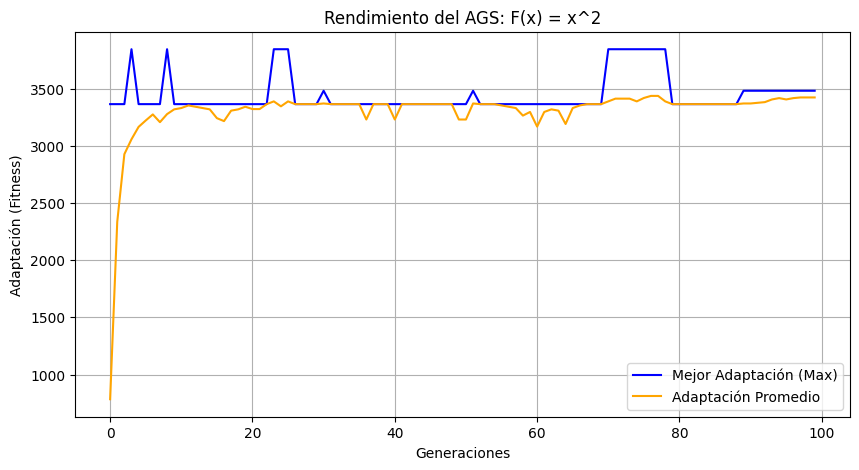

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

# PARÁMETROS DEL AGS
N = 20          # Tamaño de la población
P_c = 0.8       # Probabilidad de cruce
P_m = 0.002     # Probabilidad de mutación
G = 100         # Número de generaciones
L = 6           # Longitud del cromosoma (6 bits para representar de 0 a 63)

# FUNCIONES BASE
def fitness(x):
    """Función de adaptación F(x) = x^2."""
    return x**2

def decode(chromosome):
    """Convierte la lista binaria en un número entero."""
    return int("".join(str(bit) for bit in chromosome), 2)

def init_population(pop_size, bits):
    """Inicializa la población de forma aleatoria."""
    return [[random.randint(0, 1) for _ in range(bits)] for _ in range(pop_size)]

def roulette_selection(population, fitnesses):
    """Selección por rueda de ruleta proporcional a la adaptación."""
    total_fit = sum(fitnesses)
    # Evitar división por cero en la primera generación si todos son 0
    if total_fit == 0:
        return random.choice(population)

    pick = random.uniform(0, total_fit)
    current = 0
    for ind, fit in zip(population, fitnesses):
        current += fit
        if current >= pick:
            return ind

def crossover(p1, p2, pc):
    """Operador de cruce de un punto."""
    if random.random() < pc:
        point = random.randint(1, len(p1) - 1)
        c1 = p1[:point] + p2[point:]
        c2 = p2[:point] + p1[point:]
        return c1, c2
    return p1[:], p2[:]

def mutate(chromosome, pm):
    """Operador de mutación bit a bit."""
    for i in range(len(chromosome)):
        if random.random() < pm:
            chromosome[i] = 1 - chromosome[i]  # Invierte el bit
    return chromosome

# BUCLE PRINCIPAL DEL AGS
population = init_population(N, L)

best_fitnesses = []
avg_fitnesses = []

for gen in range(G):
    # Evaluar la población
    decoded_pop = [decode(ind) for ind in population]
    fitnesses = [fitness(x) for x in decoded_pop]

    # Registrar estadísticas (Observable a y b)
    best_fitnesses.append(max(fitnesses))
    avg_fitnesses.append(np.mean(fitnesses))

    # Generar nueva población (Sustitución Total)
    new_population = []
    while len(new_population) < N:
        # Selección
        p1 = roulette_selection(population, fitnesses)
        p2 = roulette_selection(population, fitnesses)

        # Cruce
        c1, c2 = crossover(p1, p2, P_c)

        # Mutación
        c1 = mutate(c1, P_m)
        c2 = mutate(c2, P_m)

        new_population.extend([c1, c2])

    population = new_population[:N] # Asegurar tamaño exacto

# GRÁFICAS DE EJECUCIÓN (1.1)
plt.figure(figsize=(10, 5))
plt.plot(best_fitnesses, label='Mejor Adaptación (Max)', color='blue')
plt.plot(avg_fitnesses, label='Adaptación Promedio', color='orange')
plt.title('Rendimiento del AGS: F(x) = x^2')
plt.xlabel('Generaciones')
plt.ylabel('Adaptación (Fitness)')
plt.legend()
plt.grid(True)
plt.show()

# **1.2 Cambios al reducir la probabilidad de cruce ($P_c$):**

Si fijamos $P_c=0.6$ o $P_c=0.4$ manteniendo $P_m=0.002$, se reduce la capacidad de "exploración" del algoritmo. El intercambio de material genético ocurre con menor frecuencia, por lo que la adaptación promedio (observable b) tardará más generaciones en subir, y el mejor individuo (observable a) podría estancarse temporalmente antes de alcanzar el óptimo global de 3969 (cuando $x=63$).  

Observable a (Mejor Individuo): Al disminuir la probabilidad de cruce, la velocidad de convergencia decae sensiblemente. El algoritmo pasa a depender en exceso de la población inicial aleatoria y ralentiza el descubrimiento del óptimo global ( 63 ).

Observable b (Promedio Poblacional): Al haber menos cruces, las soluciones de baja calidad tardan más en ser reemplazadas, haciendo que la curva del promedio poblacional ascienda de forma mucho más lenta en comparación con la configuración base ( Pc=0.8 ).

#**1.3 Cambios al aumentar la probabilidad de mutación ($P_m$):**

Si fijamos $P_m=0.01$ o $P_m=0.1$ manteniendo $P_c=0.8$, introducimos más "ruido" aleatorio. Con $P_m=0.01$, el algoritmo tiene mayor diversidad y evita óptimos locales. Sin embargo, con un valor muy alto como $P_m=0.1$, el comportamiento se vuelve caótico, similar a una búsqueda aleatoria pura. En la gráfica observamos que el promedio de las adaptaciones (observable b) fluctuará violentamente hacia abajo, y el mejor individuo (observable a) podría perderse entre generaciones debido a mutaciones destructivas.

Observable a (Mejor Individuo): Con  Pm=0.01 , el algoritmo suele converger velozmente debido al aporte de diversidad genética. Sin embargo, con un extremo  Pm=0.1  (10% de probabilidad de mutación por bit), la solución óptima se vuelve inestable; el algoritmo puede descubrir el máximo pero destruirlo en la siguiente generación debido a la excesiva alteración de sus bits.

Observable b (Promedio Poblacional): Al fijar  Pm=0.1 , el promedio de adaptaciones sufre un colapso drástico y muestra un comportamiento oscilatorio/ruidoso de baja eficacia. El algoritmo pierde su carácter evolutivo guiado y se degrada hacia una búsqueda puramente aleatoria.

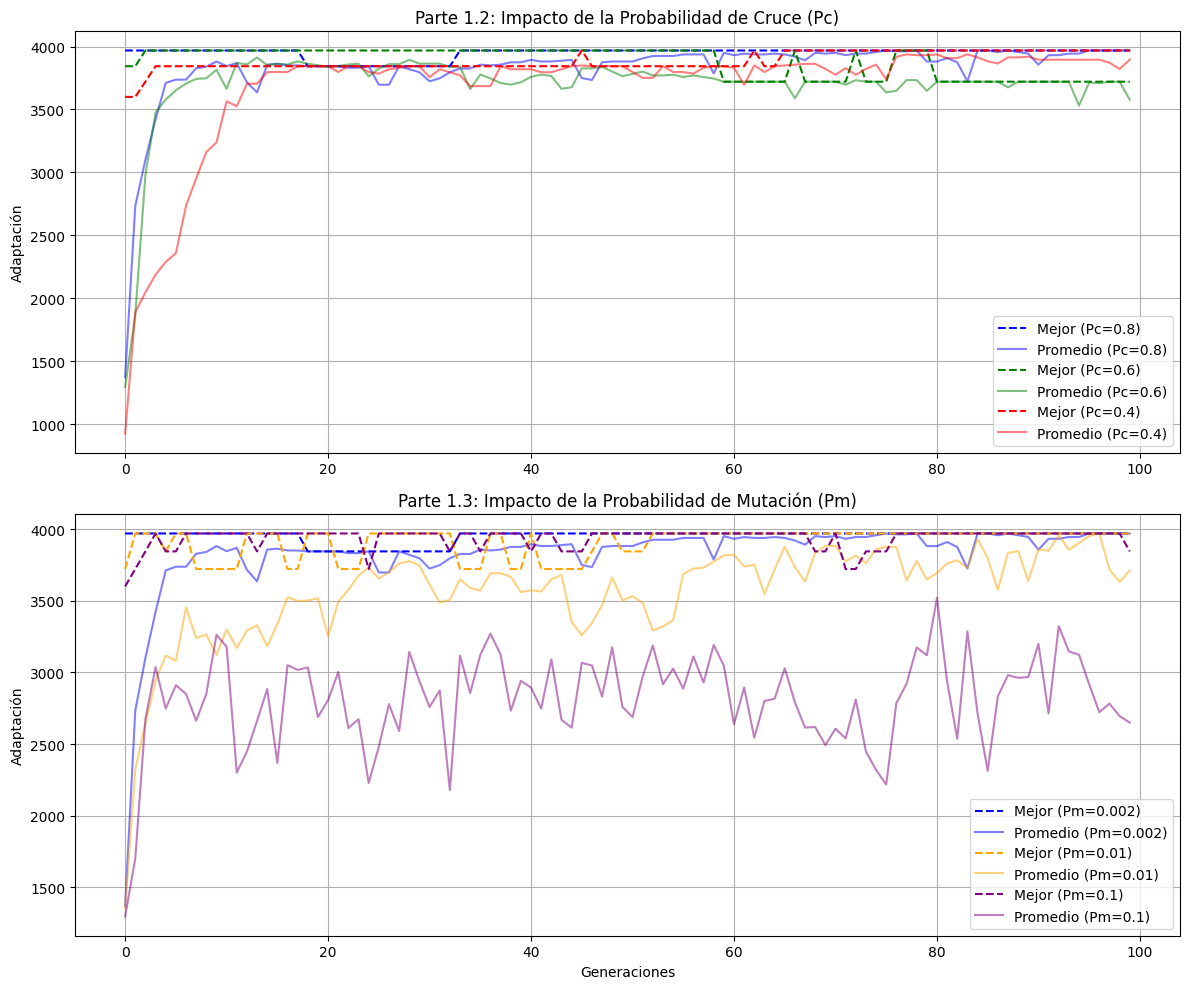

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random

# FUNCIONES BASE
def fitness(x): return x**2
def decode(chromosome): return int("".join(str(bit) for bit in chromosome), 2)
def init_population(pop_size, bits): return [[random.randint(0, 1) for _ in range(bits)] for _ in range(pop_size)]

def roulette_selection(population, fitnesses):
    total_fit = sum(fitnesses)
    if total_fit == 0: return random.choice(population)
    pick = random.uniform(0, total_fit)
    current = 0
    for ind, fit in zip(population, fitnesses):
        current += fit
        if current >= pick: return ind

def crossover(p1, p2, pc):
    if random.random() < pc:
        point = random.randint(1, len(p1) - 1)
        return p1[:point] + p2[point:], p2[:point] + p1[point:]
    return p1[:], p2[:]

def mutate(chromosome, pm):
    return [1 - bit if random.random() < pm else bit for bit in chromosome]

# ENCAPSULAMIENTO DEL AGS
def run_ga(P_c, P_m, N=20, G=100, L=6):
    """Ejecuta el AGS y retorna el historial de adaptación (mejor y promedio)."""
    population = init_population(N, L)
    best_fitnesses, avg_fitnesses = [], []

    for _ in range(G):
        decoded_pop = [decode(ind) for ind in population]
        fitnesses = [fitness(x) for x in decoded_pop]

        best_fitnesses.append(max(fitnesses))
        avg_fitnesses.append(np.mean(fitnesses))

        new_population = []
        while len(new_population) < N:
            p1 = roulette_selection(population, fitnesses)
            p2 = roulette_selection(population, fitnesses)
            c1, c2 = crossover(p1, p2, P_c)
            new_population.extend([mutate(c1, P_m), mutate(c2, P_m)])

        population = new_population[:N]

    return best_fitnesses, avg_fitnesses

# EXPERIMENTOS Y GRÁFICAS (1.2 y 1.3)
# Ejecutamos los diferentes escenarios
# Base: Pc=0.8, Pm=0.002
best_base, avg_base = run_ga(P_c=0.8, P_m=0.002)

# Parte 1.2: Variando Pc
best_pc6, avg_pc6 = run_ga(P_c=0.6, P_m=0.002)
best_pc4, avg_pc4 = run_ga(P_c=0.4, P_m=0.002)

# Parte 1.3: Variando Pm
best_pm01, avg_pm01 = run_ga(P_c=0.8, P_m=0.01)
best_pm1, avg_pm1 = run_ga(P_c=0.8, P_m=0.1)

# Configuración de los subgráficos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Gráfica Parte 1.2 (Análisis de Pc)
ax1.plot(best_base, label='Mejor (Pc=0.8)', color='blue', linestyle='--')
ax1.plot(avg_base, label='Promedio (Pc=0.8)', color='blue', alpha=0.5)

ax1.plot(best_pc6, label='Mejor (Pc=0.6)', color='green', linestyle='--')
ax1.plot(avg_pc6, label='Promedio (Pc=0.6)', color='green', alpha=0.5)

ax1.plot(best_pc4, label='Mejor (Pc=0.4)', color='red', linestyle='--')
ax1.plot(avg_pc4, label='Promedio (Pc=0.4)', color='red', alpha=0.5)

ax1.set_title('Parte 1.2: Impacto de la Probabilidad de Cruce (Pc)')
ax1.set_ylabel('Adaptación')
ax1.legend()
ax1.grid(True)

# Gráfica Parte 1.3 (Análisis de Pm)
ax2.plot(best_base, label='Mejor (Pm=0.002)', color='blue', linestyle='--')
ax2.plot(avg_base, label='Promedio (Pm=0.002)', color='blue', alpha=0.5)

ax2.plot(best_pm01, label='Mejor (Pm=0.01)', color='orange', linestyle='--')
ax2.plot(avg_pm01, label='Promedio (Pm=0.01)', color='orange', alpha=0.5)

ax2.plot(best_pm1, label='Mejor (Pm=0.1)', color='purple', linestyle='--')
ax2.plot(avg_pm1, label='Promedio (Pm=0.1)', color='purple', alpha=0.5)

ax2.set_title('Parte 1.3: Impacto de la Probabilidad de Mutación (Pm)')
ax2.set_xlabel('Generaciones')
ax2.set_ylabel('Adaptación')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# **Parte 1.4: Adaptación del AGS para Variables Reales**

Para evaluar el máximo de la función con $x$ como un número real en el intervalo [0, 63] y una precisión de 2 cifras decimales, realizamos las siguientes modificaciones:

Tamaño de la población: Se actualiza a $N = 50$.

Ya no basta con transformar el binario a entero directamente. Hay que aplicar la fórmula de mapeo lineal:$$x = L_{inf} + D \cdot \frac{L_{sup} - L_{inf}}{2^{L} - 1}$$Donde $D$ es el valor entero del cromosoma binario, $L_{inf}=0$, $L_{sup}=63$, y $L$ es la nueva longitud del cromosoma.

Longitud del cromosoma: Como demostramos teóricamente, necesitamos 6300 divisiones. El número de bits mínimo para representar esto es 13 ($2^{13} = 8192$ estados posibles). Por lo tanto, actualizamos $L = 13$.

Función de decodificación (decode_real): Esta es la modificación más importante del código. Convertimos el valor binario a entero base 10, y luego aplicamos una regla de tres (interpolación lineal) para escalar ese entero al rango real [0, 63].

RESULTADOS PARTE 1.4 
Mejor valor de x encontrado: 62.95
Máximo valor de F(x) alcanzado: 3962.7025000000003


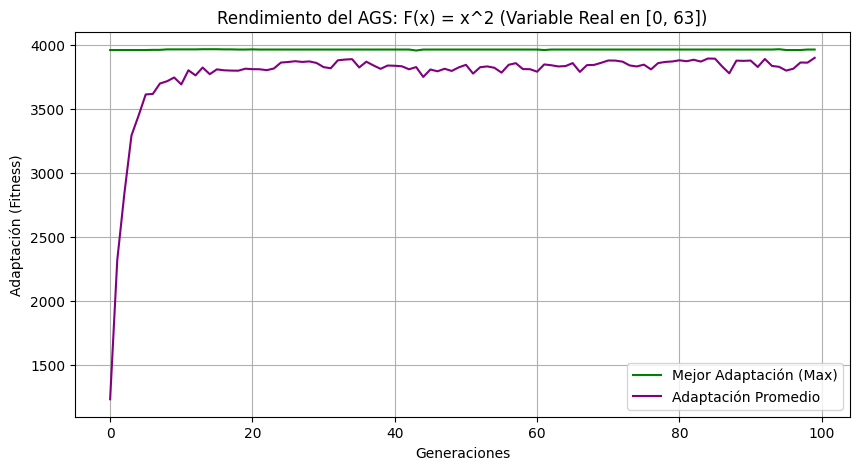

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random

# NUEVOS PARÁMETROS (Parte 1.4)
N = 50          # Nuevo tamaño de la población (aumentado a 50)
P_c = 0.8       # Probabilidad de cruce
P_m = 0.002     # Probabilidad de mutación
G = 100         # Número de generaciones
L = 13          # Nueva longitud del cromosoma (para precisión de 2 decimales)
X_MIN = 0       # Límite inferior del intervalo real
X_MAX = 63      # Límite superior del intervalo real

# --- NUEVA FUNCIÓN DE DECODIFICACIÓN REAL ---
def decode_real(chromosome):
    """
    Convierte el cromosoma binario a un número real en el intervalo [0, 63]
    con 2 cifras decimales de precisión.
    """
    # 1. Convertir la lista binaria a un entero base 10
    integer_value = int("".join(str(bit) for bit in chromosome), 2)

    # 2. Mapear el entero al rango real [X_MIN, X_MAX]
    # Fórmula: x = X_MIN + entero * (X_MAX - X_MIN) / (2^L - 1)
    max_int = (2**L) - 1
    real_value = X_MIN + integer_value * (X_MAX - X_MIN) / max_int

    # 3. Redondear a 2 cifras decimales
    return round(real_value, 2)

# FUNCIONES BASE REUTILIZADAS
def fitness(x):
    return x**2

def init_population(pop_size, bits):
    return [[random.randint(0, 1) for _ in range(bits)] for _ in range(pop_size)]

def roulette_selection(population, fitnesses):
    total_fit = sum(fitnesses)
    if total_fit == 0:
        return random.choice(population)
    pick = random.uniform(0, total_fit)
    current = 0
    for ind, fit in zip(population, fitnesses):
        current += fit
        if current >= pick:
            return ind

def crossover(p1, p2, pc):
    if random.random() < pc:
        point = random.randint(1, len(p1) - 1)
        c1 = p1[:point] + p2[point:]
        c2 = p2[:point] + p1[point:]
        return c1, c2
    return p1[:], p2[:]

def mutate(chromosome, pm):
    for i in range(len(chromosome)):
        if random.random() < pm:
            chromosome[i] = 1 - chromosome[i]
    return chromosome

# BUCLE PRINCIPAL DEL AGS
population = init_population(N, L)

best_fitnesses = []
avg_fitnesses = []

for gen in range(G):
    # Evaluar la población decodificando a números reales
    decoded_pop = [decode_real(ind) for ind in population]
    fitnesses = [fitness(x) for x in decoded_pop]

    # Registrar estadísticas
    best_fitnesses.append(max(fitnesses))
    avg_fitnesses.append(np.mean(fitnesses))

    # Generar nueva población
    new_population = []
    while len(new_population) < N:
        p1 = roulette_selection(population, fitnesses)
        p2 = roulette_selection(population, fitnesses)

        c1, c2 = crossover(p1, p2, P_c)

        c1 = mutate(c1, P_m)
        c2 = mutate(c2, P_m)

        new_population.extend([c1, c2])

    population = new_population[:N] # Mantener el tamaño de población exacto

# ANÁLISIS DE RESULTADOS
# Encontrar el mejor individuo de la última generación
decoded_pop = [decode_real(ind) for ind in population]
fitnesses = [fitness(x) for x in decoded_pop]
best_index = np.argmax(fitnesses)
best_x = decoded_pop[best_index]
best_fit = fitnesses[best_index]

print("RESULTADOS PARTE 1.4 ")
print(f"Mejor valor de x encontrado: {best_x}")
print(f"Máximo valor de F(x) alcanzado: {best_fit}")

#  GRÁFICAS
plt.figure(figsize=(10, 5))
plt.plot(best_fitnesses, label='Mejor Adaptación (Max)', color='green')
plt.plot(avg_fitnesses, label='Adaptación Promedio', color='purple')
plt.title('Rendimiento del AGS: F(x) = x^2 (Variable Real en [0, 63])')
plt.xlabel('Generaciones')
plt.ylabel('Adaptación (Fitness)')
plt.legend()
plt.grid(True)
plt.show()